In [54]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.decomposition import PCA

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet

In [2]:
df = pd.read_csv("final_combined_data.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Ticker,Return,Volatility,Volume_Zscore,Return_Zscore,Manipulation_Flag,stock,sentiment_score,risk_score,event_count,twitter_sentiment
0,2018-01-02,39.986349,40.489233,39.774854,40.479832,102223600,AAPL,0.000000,0.014841,-0.092570,0.000000,0,AAPL,0.5,1.0,0.0,0.5
1,2018-01-03,40.543277,41.017963,40.409333,40.472778,118071600,AAPL,-0.000174,0.014841,0.194878,-0.070361,0,AAPL,0.5,1.0,0.0,0.5
2,2018-01-04,40.545623,40.764168,40.437528,40.660770,89738400,AAPL,0.004645,0.014841,-0.319025,0.171144,0,AAPL,0.5,1.0,0.0,0.5
3,2018-01-05,40.757138,41.210672,40.665491,41.123726,94640000,AAPL,0.011386,0.014841,-0.230121,0.508955,0,AAPL,0.5,1.0,0.0,0.5
4,2018-01-08,40.970982,41.267071,40.872282,40.970982,82271200,AAPL,-0.003714,0.014841,-0.454464,-0.247764,0,AAPL,0.5,1.0,0.0,0.5


1. A high return is desirable — but not if it's paired with high volatility. Return_Volatility helps models recognize unusual events where both are extreme.
2. Zscore_Product Combines volume and return anomalies. Together (extreme z-scores) often signal market manipulation, pump-and-dump, or insider activity. reference: https://medium.com/@akashsri306/detecting-anomalies-with-z-scores-a-practical-approach-2f9a0f27458d 
3. Sentiment Difference captures misalignment between regulatory disclosures and public social sentiment. "Discrepancies between formal financial statements and public perception may indicate attempts to inflate investor confidence." reference: https://ssrn.com/abstract=1331573 
4. Smoothing (3-day rolling mean): Reduces noise and highlights underlying trends in Return, Volatility, etc. This makes anomalies more meaningful.
5. 5-day Mean/Std: Captures weekly trends to help differentiate between normal fluctuations and rare anomalies.

In [3]:
# Return × Volatility
df['Return_Volatility'] = df['Return'] * df['Volatility']

# Z-score Product (Volume × Return Z-score)
df['Zscore_Product'] = df['Volume_Zscore'] * df['Return_Zscore']

# Sentiment Differential (SEC - Twitter)
df['Sentiment_Diff'] = df['sentiment_score'] - df['twitter_sentiment']

# Smoothing: 3-day moving average for core numeric signals
for col in ['Return', 'Volatility', 'Volume_Zscore', 'Return_Zscore']:
    df[f'{col}_smooth'] = df.groupby('stock')[col].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# Rolling 5-day mean & std
for col in ['Return', 'Volatility']:
    df[f'{col}_roll5_mean'] = df.groupby('stock')[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    df[f'{col}_roll5_std'] = df.groupby('stock')[col].transform(lambda x: x.rolling(window=5, min_periods=1).std())


# Selecting features for modeling
features_to_use = [
    'Return', 'Volatility', 'Volume_Zscore', 'Return_Zscore',
    'risk_score', 'sentiment_score', 'twitter_sentiment',
    'Return_Volatility', 'Zscore_Product', 'Sentiment_Diff'
]

features_to_use = [
    'Return', 'Volatility', 'Volume_Zscore', 'Return_Zscore',
    'risk_score', 'sentiment_score', 'twitter_sentiment',
    'Return_Volatility', 'Zscore_Product', 'Sentiment_Diff',
    'Return_smooth', 'Volatility_smooth', 'Volume_Zscore_smooth', 'Return_Zscore_smooth',
    'Return_roll5_mean', 'Volatility_roll5_mean', 'Return_roll5_std', 'Volatility_roll5_std'
]

df_to_use = df[features_to_use].dropna()

In [4]:
# X = df.drop(columns=['Date', 'stock', 'Ticker'])  # drop non-feature columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_to_use)
X = pd.DataFrame(X_scaled, columns=features_to_use)
display(X.head())

,Return,Volatility,Volume_Zscore,Return_Zscore,risk_score,sentiment_score,twitter_sentiment,Return_Volatility,Zscore_Product,Sentiment_Diff,Return_smooth,Volatility_smooth,Volume_Zscore_smooth,Return_Zscore_smooth,Return_roll5_mean,Volatility_roll5_mean,Return_roll5_std,Volatility_roll5_std
0,-0.021746,-0.67321,0.194581,-0.070387,-0.159304,-0.07782,-0.279293,-0.018287,-0.047654,0.252854,-0.034723,-0.697448,0.057319,-0.060243,-0.043672,-0.72149,-0.907444,-0.529849
1,0.045556,-0.67321,-0.319370,0.171207,-0.159304,-0.07782,-0.279293,-0.016214,-0.055875,0.252854,0.002192,-0.697448,-0.080694,0.056772,0.002615,-0.72149,-0.857382,-0.529849
2,0.139695,-0.67321,-0.230457,0.509142,-0.159304,-0.07782,-0.279293,-0.013313,-0.068448,0.252854,0.091015,-0.697448,-0.131977,0.345422,0.075212,-0.72149,-0.805704,-0.529849
3,-0.071184,-0.67321,-0.454821,-0.247855,-0.159304,-0.07782,-0.279293,-0.019811,-0.022254,0.252854,0.063398,-0.697448,-0.374071,0.244809,0.030147,-0.72149,-0.798158,-0.529849
4,-0.020916,-0.67321,-0.381088,-0.067407,-0.159304,-0.07782,-0.279293,-0.018262,-0.039737,0.252854,0.026267,-0.697448,-0.397079,0.109531,0.029473,-0.72149,-0.797924,-0.529849


## Clustering Models

### KMeans
Groups data into fixed clusters, helping spot general behavior categories.

### DBSCAN 
Identifies dense regions and flags low-density outliers as anomalies.

Reference: https://scikit-learn.org/stable/modules/clustering.html 


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'] = -1
df.loc[df_to_use.index, 'kmeans_cluster'] = kmeans_labels


In [6]:
dbscan = DBSCAN(eps=1.2, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['dbscan_cluster'] = -1
df.loc[df_to_use.index, 'dbscan_cluster'] = dbscan_labels

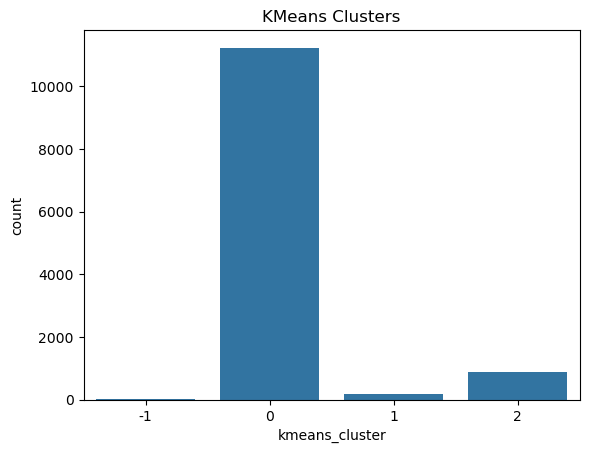

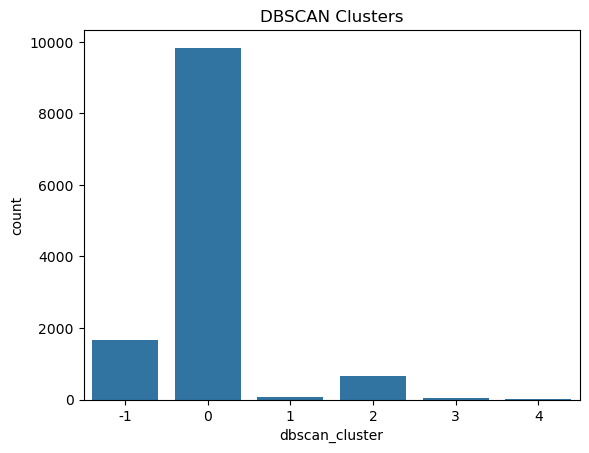

In [7]:
sns.countplot(x='kmeans_cluster', data=df)
plt.title("KMeans Clusters")
plt.show()

sns.countplot(x='dbscan_cluster', data=df)
plt.title("DBSCAN Clusters")
plt.show()

## Anomaly Detection Models

### Peer Group Analysis (PGA)
This technique compares each record’s feature to a local peer group, flagging statistical outliers.

Reference: https://doi.org/10.1109/ICDEW.2006.157 

In [8]:
# def peer_group_analysis(df, feature, group_size=20, z_thresh=2.5):
#     '''
#     df: The input DataFrame
#     group_col: The column which should be analysed (e.g., Return) 
#     group_size: The column used to define the peer group size
#     z_thresh: Z-score threshold to determine anomalies (default is 2.5)
#     '''
#     df = df.sort_values(feature) # Sorts the dataset by the defined feature
#     anomalies = []
#     for i in range(len(df)):
#         peer_start = max(i - group_size // 2, 0) # Start index of peer group
#         peer_end = min(i + group_size // 2, len(df)) # End index of peer group
#         peer_group = df.iloc[peer_start:peer_end]
#         mean = peer_group[feature].mean()
#         std = peer_group[feature].std()
#         z_score = (df.iloc[i][feature] - mean) / (std if std > 0 else 1) # Calculates the Z-score of the current row relative to its peer group.
#         # Flags as anomaly (1) if the Z-score exceeds the threshold 
#         if abs(z_score) > z_thresh:
#             anomalies.append(1)
#         else:
#             anomalies.append(0)
#     return anomalies


# df['pga_anomaly'] = peer_group_analysis(df_to_use.reset_index(), 'Return')

def peer_group_analysis(df, group_col, value_col, z_thresh=2.5):
    '''
    This function detects outliers/anomalies using the Peer Group Analysis (PGA) method.
    Args:
        df: The input DataFrame
        group_col: The column by which the data should be grouped (e.g., stock)
        value_col: The numerical column to assess for anomalies (e.g., Zscore_Product)
        z_thresh: Z-score threshold to determine anomalies (default is 2.5)
    
    '''
    anomaly_flags = []
    for stock, group in df.groupby(group_col):
        values = group[value_col] # Extracts the values (e.g., Zscore_Product) for current stock group
        if len(values) < 5:
            anomaly_flags.extend([0] * len(group))  # If the group has fewer than 5 records, skip analysis and assign 0 (not anomaly) to all.
            continue
        mean = values.mean()
        std = values.std()
        zscores = (values - mean) / std
        flags = (np.abs(zscores) > z_thresh).astype(int) # Compares absolute Z-scores to the threshold. If greater than z_thresh, flag as anomaly 1, else 0.
        anomaly_flags.extend(flags)
    return pd.Series(anomaly_flags, index=df.index)

df['pga_anomaly'] = peer_group_analysis(df, group_col='stock', value_col='Zscore_Product')

### Isolation Forest
A popular unsupervised anomaly detection algorithm that learns from "normal" data and scores anomalies (isolates outliers in data within a forest of random trees)

Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html

In [10]:
iso = IsolationForest(n_estimators=100, contamination=0.005, random_state=42)
iso.fit(X_scaled)
iso_scores = -iso.decision_function(X_scaled)  # negative sign ensures that higher means more anomalous

df['iso_anomaly_score'] = np.nan  # Initialize full column
df.loc[df_to_use.index, 'iso_anomaly_score'] = iso_scores
df

,Date,Open,High,Low,Close,Volume,Ticker,Return,Volatility,Volume_Zscore,...,Volume_Zscore_smooth,Return_Zscore_smooth,Return_roll5_mean,Return_roll5_std,Volatility_roll5_mean,Volatility_roll5_std,kmeans_cluster,dbscan_cluster,pga_anomaly,iso_anomaly_score
0,2018-01-02,39.986349,40.489233,39.774854,40.479832,102223600,AAPL,0.000000,0.014841,-0.092570,...,-0.092570,0.000000,0.000000,NaN,0.014841,NaN,-1,-1,0,NaN
1,2018-01-03,40.543277,41.017963,40.409333,40.472778,118071600,AAPL,-0.000174,0.014841,0.194878,...,0.051154,-0.035181,-0.000087,0.000123,0.014841,0.000000,0,0,0,-0.347321
2,2018-01-04,40.545623,40.764168,40.437528,40.660770,89738400,AAPL,0.004645,0.014841,-0.319025,...,-0.072239,0.033594,0.001490,0.002733,0.014841,0.000000,0,0,0,-0.352579
3,2018-01-05,40.757138,41.210672,40.665491,41.123726,94640000,AAPL,0.011386,0.014841,-0.230121,...,-0.118089,0.203246,0.003964,0.005428,0.014841,0.000000,0,0,0,-0.350996
4,2018-01-08,40.970982,41.267071,40.872282,40.970982,82271200,AAPL,-0.003714,0.014841,-0.454464,...,-0.334537,0.144112,0.002428,0.005821,0.014841,0.000000,0,0,0,-0.348211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12291,2023-12-22,0.211000,0.220000,0.210000,0.217600,4682395,ZOM,0.003690,0.076343,-0.300652,...,-0.251698,-0.050547,0.053530,0.087089,0.072728,0.008656,0,0,0,-0.326214
12292,2023-12-26,0.216800,0.228500,0.214500,0.221900,9352873,ZOM,0.019761,0.072518,-0.210634,...,-0.260717,0.308104,0.030424,0.074369,0.075571,0.003580,0,0,0,-0.331443
12293,2023-12-27,0.222500,0.228400,0.211000,0.215000,5095105,ZOM,-0.031095,0.078142,-0.292697,...,-0.267994,-0.048762,-0.003878,0.044516,0.076612,0.003374,0,0,0,-0.340432
12294,2023-12-28,0.216000,0.218200,0.207000,0.210000,4325280,ZOM,-0.023256,0.066950,-0.307534,...,-0.270288,-0.165318,0.004101,0.033430,0.073727,0.004320,0,0,0,-0.348977


### Autoencoder-based
A type of neural network specialized in learning how to compress input data into a smaller representation and then reconstruct it back to the original form. I applied unsupervised anomaly detection using an autoencoder neural network to identify potential stock manipulation events without relying on labeled ground truth data. 
 - When trained on mostly normal data, the autoencoder learns the typical patterns and relationships among features like return, volatility, risk scores, and sentiment.
 - When given a new data point, the model tries to reconstruct it from its learned representation.
 - If the new point is similar to the normal patterns, it will reconstruct well with a low reconstruction error.
 - If the point is very different (anomalous), the autoencoder will struggle to reconstruct it accurately, resulting in a high reconstruction error.

 Reference: https://keras.io/examples/timeseries/timeseries_anomaly_detection/

In [ ]:
input_dim = X_scaled.shape[1]

# a feedforward neural network with layers that compress and decompress the feature space.
autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])
autoencoder.compile(optimizer='adam', loss='mse')

#Training the model using all available data, as the majority of days reflect normal trading behavior.
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=256, validation_split=0.1, verbose=0)

reconstructions = autoencoder.predict(X_scaled)
reconstruction_errors = np.mean(np.square(X_scaled - reconstructions), axis=1) # average squared difference between each day’s input and its reconstruction

df['autoencoder_error'] = np.nan  # Initialize full column
df.loc[df_to_use.index, 'autoencoder_error'] = reconstruction_errors

# Ranking all stock-days by their reconstruction errors
top_anomalies = df.sort_values('autoencoder_error', ascending=False).head(10)
print(top_anomalies[['Date', 'stock', 'autoencoder_error', 'iso_anomaly_score', 'Manipulation_Flag']])

384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step
             Date stock  autoencoder_error  iso_anomaly_score
2281   2021-01-27   AMC           5.900617           0.115110
3789   2021-01-26   GME           0.530022           0.091121
2283   2021-01-29   AMC           0.529145           0.105255
11548  2021-01-11   ZOM           0.503475           0.037373
3809   2021-02-24   GME           0.430338           0.072460
3790   2021-01-27   GME           0.428706           0.106776
2282   2021-01-28   AMC           0.427854           0.100781
6760   2023-11-10  PLUG           0.397289          -0.023547
2286   2021-02-03   AMC           0.378615           0.015062
2288   2021-02-05   AMC           0.333182          -0.022767


In [ ]:
# df.to_csv("modeled_cluster_anomaly_data.csv", index=False)

In [13]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'Return',
       'Volatility', 'Volume_Zscore', 'Return_Zscore', 'Manipulation_Flag',
       'stock', 'sentiment_score', 'risk_score', 'event_count',
       'twitter_sentiment', 'Return_Volatility', 'Zscore_Product',
       'Sentiment_Diff', 'Return_smooth', 'Volatility_smooth',
       'Volume_Zscore_smooth', 'Return_Zscore_smooth', 'Return_roll5_mean',
       'Return_roll5_std', 'Volatility_roll5_mean', 'Volatility_roll5_std',
       'kmeans_cluster', 'dbscan_cluster', 'pga_anomaly', 'iso_anomaly_score',
       'autoencoder_error'],
      dtype='object')

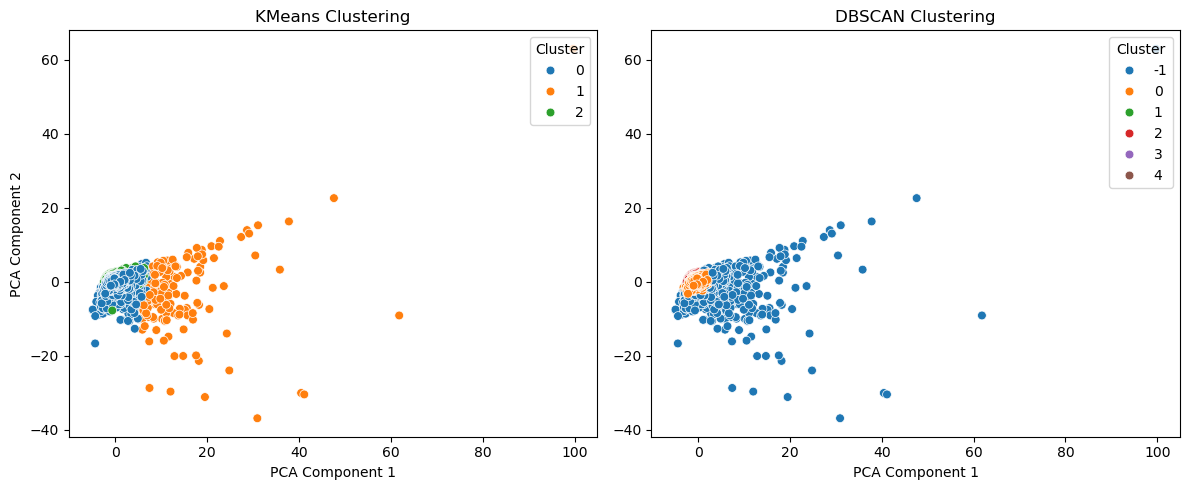

In [34]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_vis = df.loc[df_to_use.index].copy()
df_vis['pca_1'] = X_pca[:, 0]
df_vis['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(12, 5))

# 1. KMeans Clusters
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_vis, x='pca_1', y='pca_2', hue='kmeans_cluster', palette='tab10', s=40)
plt.title("KMeans Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster", loc='upper right')

# 2. DBSCAN Clusters
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_vis, x='pca_1', y='pca_2', hue='dbscan_cluster', palette='tab10', s=40)
plt.title("DBSCAN Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("")
plt.legend(title="Cluster", loc='upper right')

plt.tight_layout()
plt.show()


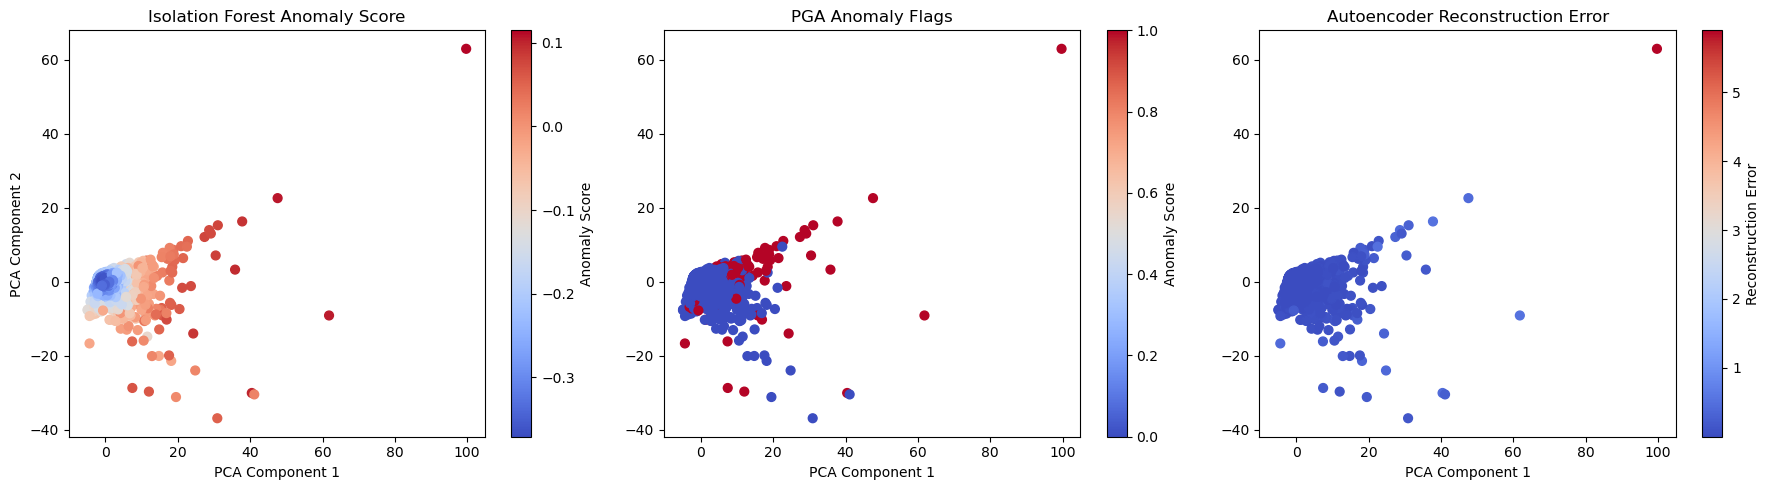

In [38]:
plt.figure(figsize=(18, 5))

# 1. Isolation Forest Scores
plt.subplot(1, 3, 1)
scatter = plt.scatter(df_vis['pca_1'], df_vis['pca_2'], c=df_vis['iso_anomaly_score'], cmap='coolwarm', s=40)
plt.colorbar(scatter, label="Anomaly Score")
plt.title("Isolation Forest Anomaly Score")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# 3. PGA Anomalies
plt.subplot(1, 3, 2)
scatter = plt.scatter(df_vis['pca_1'], df_vis['pca_2'], c=df_vis['pga_anomaly'], cmap='coolwarm', s=40)
plt.colorbar(scatter, label="Anomaly Score")
# sns.scatterplot(data=df_vis, x='pca_1', y='pca_2', hue='pga_anomaly', palette='Set1', s=40)
plt.title("PGA Anomaly Flags")
plt.xlabel("PCA Component 1")
plt.ylabel("")
# plt.legend(title="Anomaly", loc='upper right')

# 2. Autoencoder Errors
plt.subplot(1, 3, 3)
scatter = plt.scatter(df_vis['pca_1'], df_vis['pca_2'], c=df_vis['autoencoder_error'], cmap='coolwarm', s=40)
plt.colorbar(scatter, label="Reconstruction Error")
plt.title("Autoencoder Reconstruction Error")
plt.xlabel("PCA Component 1")
plt.ylabel("")

plt.tight_layout()
plt.show()


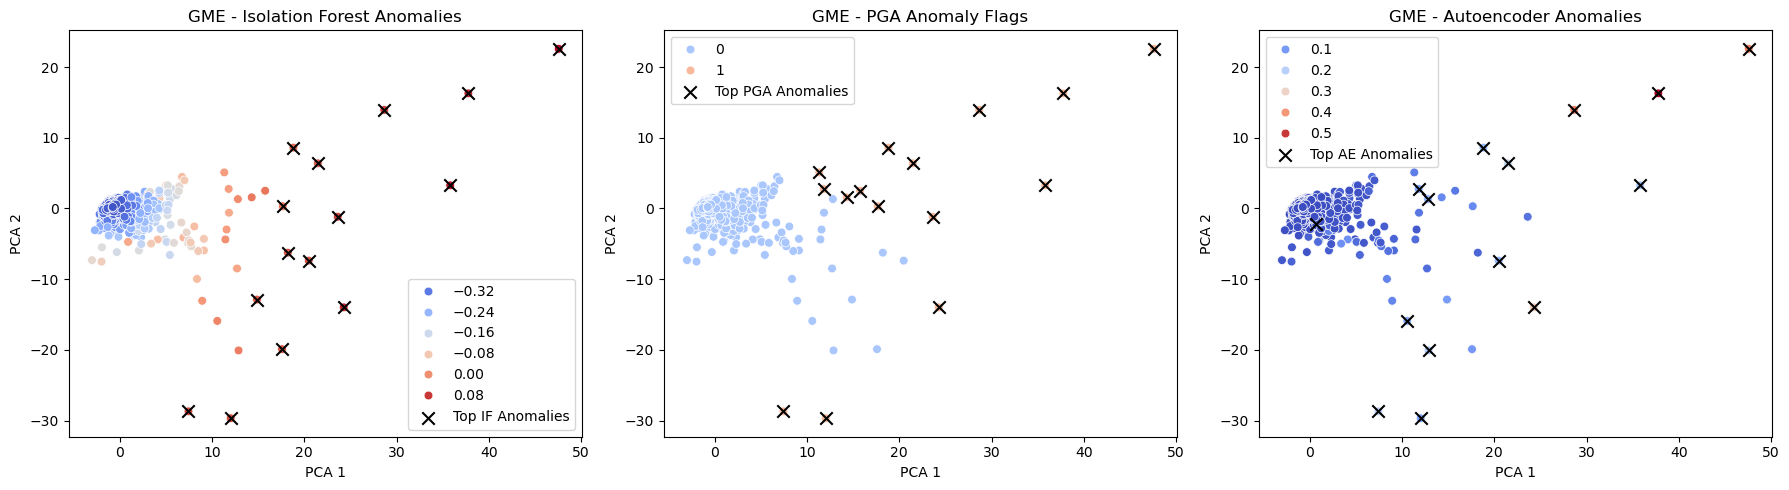

In [47]:
# Filter only GME stock
df_gme = df_vis[df_vis['stock'] == 'GME'].copy()

# Top 10 most anomalous GME days (Isolation Forest)
top_iso_gme = df_gme.sort_values('iso_anomaly_score', ascending=False).head(15)

# Top 10 most anomalous GME days (Autoencoder)
top_auto_gme = df_gme.sort_values('autoencoder_error', ascending=False).head(15)

# PGA Anomalies (flagged as 1)
pga_gme = df_gme[df_gme['pga_anomaly'] == 1]

plt.figure(figsize=(18, 5))

# Isolation Forest
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_gme, x='pca_1', y='pca_2', hue='iso_anomaly_score', palette='coolwarm', s=40)
plt.scatter(top_iso_gme['pca_1'], top_iso_gme['pca_2'], color='black', s=80, marker='x', label='Top IF Anomalies')
plt.title("GME - Isolation Forest Anomalies")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()

# Autoencoder
plt.subplot(1, 3, 3)
sns.scatterplot(data=df_gme, x='pca_1', y='pca_2', hue='autoencoder_error', palette='coolwarm', s=40)
plt.scatter(top_auto_gme['pca_1'], top_auto_gme['pca_2'], color='black', s=80, marker='x', label='Top AE Anomalies')
plt.title("GME - Autoencoder Anomalies")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()

plt.subplot(1, 3, 2)
sns.scatterplot(data=df_gme, x='pca_1', y='pca_2', hue='pga_anomaly', palette='coolwarm', s=40)
plt.scatter(pga_gme['pca_1'], pga_gme['pca_2'], color='black', s=80, marker='x', label='Top PGA Anomalies')
plt.title("GME - PGA Anomaly Flags")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()

plt.tight_layout()
plt.show()

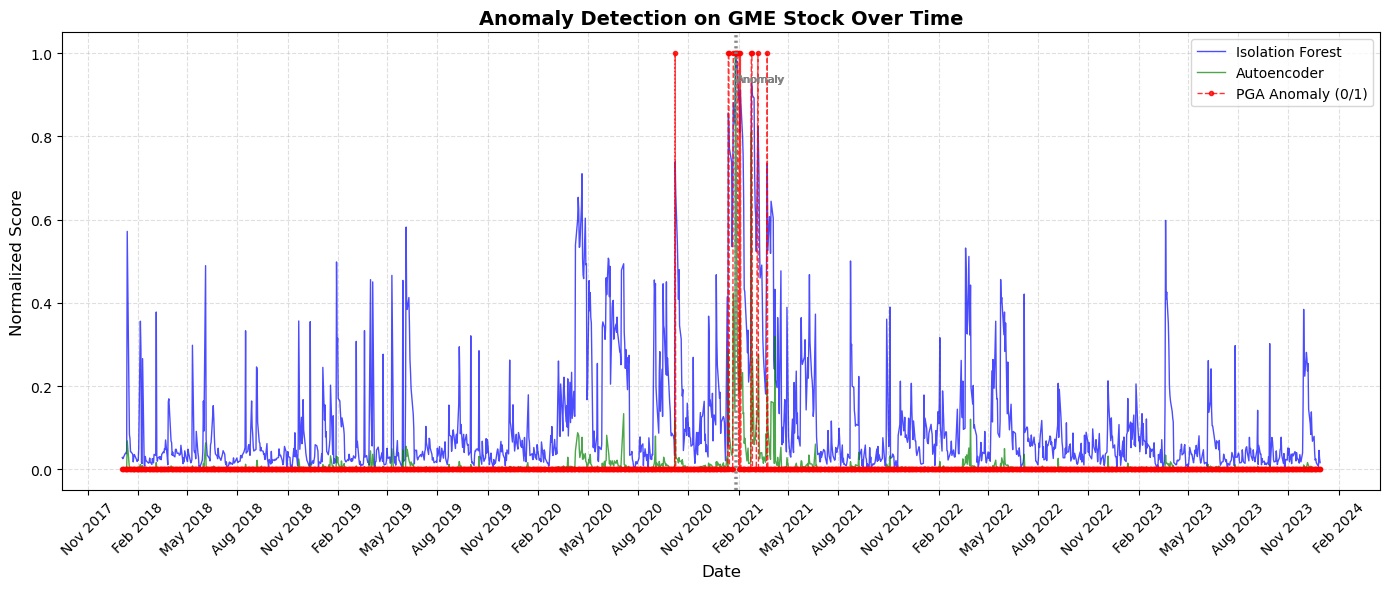

In [60]:
df_gme_scores = df_gme[['Date', 'iso_anomaly_score', 'autoencoder_error', 'pga_anomaly']].copy()
df_gme_scores['Date'] = pd.to_datetime(df_gme_scores['Date'], errors='coerce')
df_gme_scores = df_gme_scores.sort_values('Date')

scaler = MinMaxScaler()
df_gme_scores[['iso_scaled', 'ae_scaled']] = scaler.fit_transform(df_gme_scores[['iso_anomaly_score', 'autoencoder_error']])
df_gme_scores['pga_scaled'] = df_gme_scores['pga_anomaly'] 

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot lines
ax.plot(df_gme_scores['Date'], df_gme_scores['iso_scaled'], label='Isolation Forest', 
        color='blue', linewidth=1, alpha=0.7)

ax.plot(df_gme_scores['Date'], df_gme_scores['ae_scaled'], label='Autoencoder', 
        color='green', linewidth=1, alpha=0.7)

ax.plot(df_gme_scores['Date'], df_gme_scores['pga_scaled'], label='PGA Anomaly (0/1)', 
        color='red', linestyle='--', linewidth=1, marker='o', markersize=3, alpha=0.8)

# Highlight top anomalies from IF
top_anomalies = df_gme_scores.sort_values('iso_scaled', ascending=False).head(3)
for _, row in top_anomalies.iterrows():
    ax.axvline(row['Date'], color='gray', linestyle=':', alpha=0.7)
    ax.text(row['Date'], 0.95, 'Anomaly', rotation=0, verticalalignment='top', 
            color='gray', fontsize=8)

# Format X-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Layout
ax.set_title("Anomaly Detection on GME Stock Over Time", fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Normalized Score", fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Create weak labels: top 1% anomalies = 1
threshold = np.percentile(df['autoencoder_error'], 99)
df['pseudo_label'] = (df['autoencoder_error'] >= threshold).astype(int)
df


,Date,Open,High,Low,Close,Volume,Ticker,Return,Volatility,Volume_Zscore,Return_Zscore,Manipulation_Flag,stock,sentiment_score,risk_score,event_count,twitter_sentiment,iso_anomaly_score,autoencoder_error,pseudo_label
0,2018-01-02,39.986349,40.489233,39.774854,40.479832,102223600,AAPL,0.000000,0.014841,-0.092570,0.000000,0,AAPL,0.5,1.0,0.0,0.5,-0.344358,0.000099,0
1,2018-01-03,40.543277,41.017963,40.409333,40.472778,118071600,AAPL,-0.000174,0.014841,0.194878,-0.070361,0,AAPL,0.5,1.0,0.0,0.5,-0.336093,0.000107,0
2,2018-01-04,40.545623,40.764168,40.437528,40.660770,89738400,AAPL,0.004645,0.014841,-0.319025,0.171144,0,AAPL,0.5,1.0,0.0,0.5,-0.351756,0.000150,0
3,2018-01-05,40.757138,41.210672,40.665491,41.123726,94640000,AAPL,0.011386,0.014841,-0.230121,0.508955,0,AAPL,0.5,1.0,0.0,0.5,-0.341948,0.000157,0
4,2018-01-08,40.970982,41.267071,40.872282,40.970982,82271200,AAPL,-0.003714,0.014841,-0.454464,-0.247764,0,AAPL,0.5,1.0,0.0,0.5,-0.349111,0.000162,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12291,2023-12-22,0.211000,0.220000,0.210000,0.217600,4682395,ZOM,0.003690,0.076343,-0.300652,0.032187,0,ZOM,0.5,1.0,0.0,0.5,-0.355178,0.000284,0
12292,2023-12-26,0.216800,0.228500,0.214500,0.221900,9352873,ZOM,0.019761,0.072518,-0.210634,0.240736,0,ZOM,0.5,1.0,0.0,0.5,-0.354573,0.000169,0
12293,2023-12-27,0.222500,0.228400,0.211000,0.215000,5095105,ZOM,-0.031095,0.078142,-0.292697,-0.419208,0,ZOM,0.5,1.0,0.0,0.5,-0.354166,0.000199,0
12294,2023-12-28,0.216000,0.218200,0.207000,0.210000,4325280,ZOM,-0.023256,0.066950,-0.307534,-0.317481,0,ZOM,0.5,1.0,0.0,0.5,-0.356071,0.000114,0


In [89]:
threshold_if = np.percentile(df['iso_anomaly_score'], 90)
threshold_ae = np.percentile(df['autoencoder_error'], 90)
anomalies = df[(df['iso_anomaly_score'] > threshold_if) |
               (df['autoencoder_error'] > threshold_ae) |
               (df['pga_anomaly'] == 1)]

# Group by stock and list unique dates
anom_dates = {stk: sorted(anomalies[anomalies['stock']==stk]['Date'].unique())
              for stk in anomalies['stock'].unique()}
anom_dates.keys()

dict_keys(['AAPL', 'AMC', 'GME', 'GOEV', 'PLUG', 'SNDL', 'TLRY', 'TSLA', 'ZOM'])

In [119]:
df[(df['Ticker'] == 'GOEV') & (df['Date'].str.contains('2021'))]

,Date,Open,High,Low,Close,Volume,Ticker,Return,Volatility,Volume_Zscore,...,Return_Zscore_smooth,Return_roll5_mean,Return_roll5_std,Volatility_roll5_mean,Volatility_roll5_std,kmeans_cluster,dbscan_cluster,pga_anomaly,iso_anomaly_score,autoencoder_error
4532,2021-01-04,6361.800293,6371.000000,5520.000000,5750.000000,16533,GOEV,-0.094203,0.048559,-0.287855,...,-0.732997,-0.067393,0.046995,0.048559,0.000000,0,0,0,-0.300191,0.002387
4533,2021-01-05,6348.000000,6633.200195,6164.000000,6481.399902,15950,GOEV,0.127200,0.048559,-0.302811,...,0.039552,-0.014778,0.083917,0.048559,0.000000,0,0,0,-0.286431,0.009607
4534,2021-01-06,6614.800293,6941.399902,6302.000000,6458.399902,12305,GOEV,-0.003549,0.082901,-0.396323,...,0.210131,-0.005611,0.081665,0.055427,0.015358,0,0,0,-0.332635,0.006562
4535,2021-01-07,6665.399902,6794.200195,6412.399902,6527.399902,8185,GOEV,0.010684,0.069222,-0.502021,...,0.756195,0.000764,0.081389,0.059560,0.015821,0,0,0,-0.319517,0.004928
4536,2021-01-08,7084.000000,7130.000000,6490.600098,6900.000000,13423,GOEV,0.057082,0.070689,-0.367641,...,0.391147,0.019443,0.081469,0.063986,0.015051,0,0,0,-0.318966,0.002652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4779,2021-12-27,3896.200195,3928.400146,3788.100098,3836.400146,5554,GOEV,-0.019976,0.037575,-0.569519,...,-0.051544,-0.013468,0.028458,0.038666,0.001344,0,0,0,-0.360093,0.000668
4780,2021-12-28,3785.800049,3868.600098,3657.000000,3680.000000,6261,GOEV,-0.040767,0.039403,-0.551381,...,-0.166018,-0.010659,0.023644,0.038716,0.001372,0,0,0,-0.348779,0.000620
4781,2021-12-29,3675.400146,3689.199951,3482.199951,3523.600098,6291,GOEV,-0.042500,0.027001,-0.550612,...,-0.480696,-0.020816,0.024369,0.036093,0.005206,0,0,0,-0.341308,0.001392
4782,2021-12-30,3523.600098,3806.500000,3491.400146,3726.000000,12014,GOEV,0.057441,0.035823,-0.403789,...,-0.077642,-0.005572,0.042818,0.035351,0.004844,0,0,0,-0.346097,0.001886


GME News sources: https://www.reuters.com/technology/gamestop-shares-soar-short-squeeze-then-ease-wild-trade-session-2021-01-25/, https://www.washingtonpost.com/business/2021/01/27/gamestop-amc-reddit-short-sellers-wallstreetbets/, https://fortune.com/crypto/2021/02/24/gamestop-rally-round-2-reddit-gme/ , https://en.wikipedia.org/wiki/MOASS , https://fortune.com/2024/06/15/gamestop-stock-craze-keith-gill-roaring-kitty-market-manipulation-meme-stock-investing/ 

AMC News sources: https://www.tradingsim.com/blog/the-amc-short-squeeze-explanation-tradingsim , https://www.reuters.com/business/2-no-let-up-short-squeeze-retail-frenzy-forces-funds-cover-2021-01-27/ , https://www.investors.com/research/meme-stocks-buy-now-april-2025/ , https://www.forbes.com/sites/willskipworth/2023/09/06/amc-stock-plunges-over-20-as-it-announces-40-million-new-shares-to-raise-funds/ 

GOEV News sources: https://www.nasdaq.com/articles/canoos-wild-ride%3A-decoding-the-surge-in-goev-stock-amid-short-covering-speculation , https://www.tipranks.com/news/why-is-penny-stock-canoo-nasdaqgoev-spiking , https://www.prnewswire.com/news-releases/hagens-berman-national-trial-attorneys-encourages-canoo-goev-investors-with-losses-to-contact-its-attorneys-now-securities-fraud-case-filed-301264962.html , https://www.prnewswire.com/news-releases/pomerantz-law-firm-announces-the-filing-of-a-class-action-against-canoo-inc-and-certain-officers--goev-goevw-hcac-hcacw-301266150.html
On 2023-08-28, Company announced appointment of new CFO Greg Ethridge, hence, stock spiked after CFO news which is not manipulation but system marks it as anomaly. https://www.stocktitan.net/news/GOEV/canoo-names-ethridge-chief-financial-1qmq94lghjp5.html

SNDL News Sources: https://www.nasdaq.com/articles/why-is-everyone-talking-about-sundial-growers-stock-2021-02-06 , https://marketrealist.com/p/is-sundial-growers-sndl-a-good-stock-to-buy/ , https://jkci.medium.com/meme-stocks-the-internets-stock-picks-for-2021-gme-amc-bb-clov-and-more-72afc175fdb 

TLRY News Sources: https://www.nasdaq.com/articles/tlry-stock-short-squeeze-alert%3A-is-tilray-the-next-gamestop-2021-02-11 , https://www.fool.com/investing/2021/01/06/pot-stocks-are-on-a-big-election-high-as-markets-j/ 

ZOM News Sources: https://www.nasdaq.com/articles/is-zomedica-stock-worth-the-risk-unfortunately-its-complicated-2021-09-08 , 

In [ ]:
manual_labels = []

for stock, dates in anom_dates.items():
    for dt in dates:
        manipulation_label = 1 if (
            (stock == 'GME' and dt in ['2020-10-08', '2021-01-13', '2021-01-14', '2021-01-22',
                                       '2021-01-25', '2021-01-26', '2021-01-27', '2021-01-28',
                                       '2021-01-29', '2021-02-24', '2021-06-07']) or
            (stock == 'AMC' and dt in ['2021-01-27', '2021-01-28', '2021-01-29',
                                       '2021-06-02', '2023-09-06', '2021-06-07']) or 
            (stock == 'GOEV' and dt in ['2020-12-24', '2021-03-29', '2022-07-14', '2023-11-20']) or 
            (stock == 'SNDL' and dt in ['2021-01-28', '2021-02-01', '2021-02-09', 
                                        '2021-02-10', '2021-02-11', '2021-03-29']) or 
            (stock == 'TLRY' and dt in ['2021-01-14', '2021-02-09', '2021-02-10', '2021-02-11']) or 
            (stock == 'ZOM' and dt in ['2021-01-04', '2021-01-05', '2021-01-08', 
                                       '2021-01-12', '2021-01-13', '2021-02-04', 
                                       '2021-02-05', '2021-02-08', '2021-02-09'])
        ) else 0
        event_label = 1 if (
            (stock == 'GOEV' and dt in ['2022-07-12', '2023-08-28']) or
            (stock == 'PLUG' and dt in ['2020-06-23', '2021-01-27']) or 
            (stock == 'AAPL' and dt in ['2018-02-02', '2018-02-06', '2018-05-02',
                                        '2018-11-02', '2018-12-21', '2019-01-03',
                                        '2019-05-13', '2020-02-27', '2020-03-02',
                                        '2020-03-03', '2020-03-09', '2020-03-10', 
                                        '2020-03-12', '2020-03-13', '2020-03-16', 
                                        '2020-03-17', '2020-03-20', '2020-03-24', 
                                        '2020-03-26', '2020-04-06', '2020-07-31', 
                                        '2020-09-03', '2020-09-08']) or 
            (stock == 'SNDL' and dt in ['2020-11-09', '2021-02-01', '2021-02-01', 
                                        '2021-02-10', '2021-02-11']) or 
            (stock == 'TLRY' and dt in ['2021-01-14', '2021-02-09', '2021-02-10', 
                                        '2021-02-11', '2021-07-28', '2023-08-08', 
                                        '2020-12-16', '2020-03-26']) or
            (stock == 'TSLA' and dt in ['2018-08-02', '2018-08-07', '2018-09-28', 
                                        '2018-10-01', '2020-02-27', '2020-03-02', 
                                        '2020-03-12', '2020-03-16', '2020-03-18', 
                                        '2020-03-19', '2020-03-24', '2020-08-31', 
                                        '2023-01-27']) or 
            (stock == 'ZOM' and dt in['2020-11-13', '2020-11-17'])
        ) else 0
        manual_labels.append({'stock': stock, 'Date': dt, 'event_flag': event_label, 'manual_manipulation_flag': manipulation_label})

df_manual = pd.DataFrame(manual_labels)

In [ ]:
df = df.merge(df_manual, on=['stock', 'Date'], how='left')
df['manual_manipulation_flag'] = df['manual_manipulation_flag'].fillna(0).astype(int)
df['event_flag'] = df['event_flag'].fillna(0).astype(int)


In [ ]:
from sklearn.metrics import precision_score, recall_score
print("Precision:", precision_score(df['manual_flag'], df['pga_anomaly']))
print("Recall:", recall_score(df['manual_flag'], df['pga_anomaly']))

## Classification

### Random Forest Classifier
We use anomaly-based pseudo-labels to train RandomForest classifier

In [8]:
X_supervised = X_scaled
y_supervised = df['pseudo_label']

clf = RandomForestClassifier(class_weight='balanced')
clf.fit(X_supervised, y_supervised)

y_scores = clf.predict_proba(X_supervised)[:,1]
pr_auc = average_precision_score(y_supervised, y_scores)
print(f"Random Forest PR-AUC on pseudo-labels: {pr_auc:.3f}")

y_pred = clf.predict(X_supervised)
print(classification_report(y_supervised, y_pred))

Random Forest PR-AUC on pseudo-labels: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12173
           1       1.00      1.00      1.00       123

    accuracy                           1.00     12296
   macro avg       1.00      1.00      1.00     12296
weighted avg       1.00      1.00      1.00     12296



###  Transformer-Based Models for Time-Series